# Openness and Closeness in Seabed Morphological Mapping

**Context:** This notebook explains the concepts of *topographic openness* and *closeness* as used in the GA-SaMMT (Geoscience Australia's Semi-automated Morphological Mapping Tools) for characterising seabed features from bathymetric data.

**References:**
- Yokoyama, R., Shirasawa, M., & Pike, R. J. (2002). Visualizing topography by openness: A new application of image processing to digital elevation models. *Photogrammetric Engineering and Remote Sensing*, 68(3), 257–265.
- Huang, Z., Nanson, R., McNeil, M., Wenderlich, M., Gafeira, J., Post, A, Nichol, S. (2023). Rule-based semi-automated tools for mapping seabed morphology from bathymetry data. *Frontiers in Marine Science*, 10, 1236788.

---

## 1. What is Topographic Openness?

**Topographic openness** is a terrain attribute that quantifies how *open* or *enclosed* a location is relative to its surrounding landscape. It was introduced by Yokoyama et al. (2002) originally for land topography, and has since been adapted for bathymetric (underwater) terrain analysis.

The concept is based on **zenith angles** — angles measured upward from a horizontal plane to the terrain surface along radial lines emanating from a central point.

For a given point on the terrain:
- We cast rays outward in multiple directions (typically 8 principal directions: N, NE, E, SE, S, SW, W, NW).
- Along each ray, we find the **maximum zenith angle** to the horizon (the steepest upward angle we can "see").
- We average these angles across all directions.

There are **two complementary measures**:

| Measure | Symbol | Intuition |
|---|---|---|
| **Positive Openness (PO)** | Ψ⁺ | How open is the sky above? High = open terrain (ridges, hills) |
| **Negative Openness (NO)** | Ψ⁻ | How enclosed is the terrain below? High = enclosed terrain (valleys, pits) |

## 2. Mathematical Definition

For a point $P$ on a digital elevation model (DEM) or bathymetric grid, consider $n$ radial directions (usually $n = 8$). For each direction $i$, we search along a line of length $L$ (the **search radius** in cell units).

### Positive Openness

For each direction $i$, find the **maximum elevation angle** $\alpha_i$ to any point along that radial line:

$$\alpha_i = \max_{d=1}^{L} \arctan\left(\frac{z(d) - z(P)}{d \cdot \Delta x}\right)$$

where:
- $z(d)$ = elevation at distance $d$ along the radial line
- $z(P)$ = elevation at the central point
- $\Delta x$ = grid cell size

The **Positive Openness** is:

$$\Psi^+ = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{\pi}{2} - \alpha_i\right)$$

This is the mean **zenith angle** — $90°$ minus the maximum elevation angle in each direction.

### Negative Openness

For each direction $i$, find the **minimum depression angle** $\beta_i$ (looking downward):

$$\beta_i = \max_{d=1}^{L} \arctan\left(\frac{z(P) - z(d)}{d \cdot \Delta x}\right)$$

The **Negative Openness** is:

$$\Psi^- = \frac{1}{n} \sum_{i=1}^{n} \left(\frac{\pi}{2} - \beta_i\right)$$

> **Key insight:** Both openness values range from 0 to π/2 radians (0° to 180°). **Higher positive openness** → more exposed / convex terrain. **Lower negative openness** (or equivalently, higher closeness) → more enclosed / concave terrain.

## 3. Visual Intuition

The diagram below illustrates the zenith angle concept for a 2D cross-section. Imagine standing at point P and looking along a radial line:

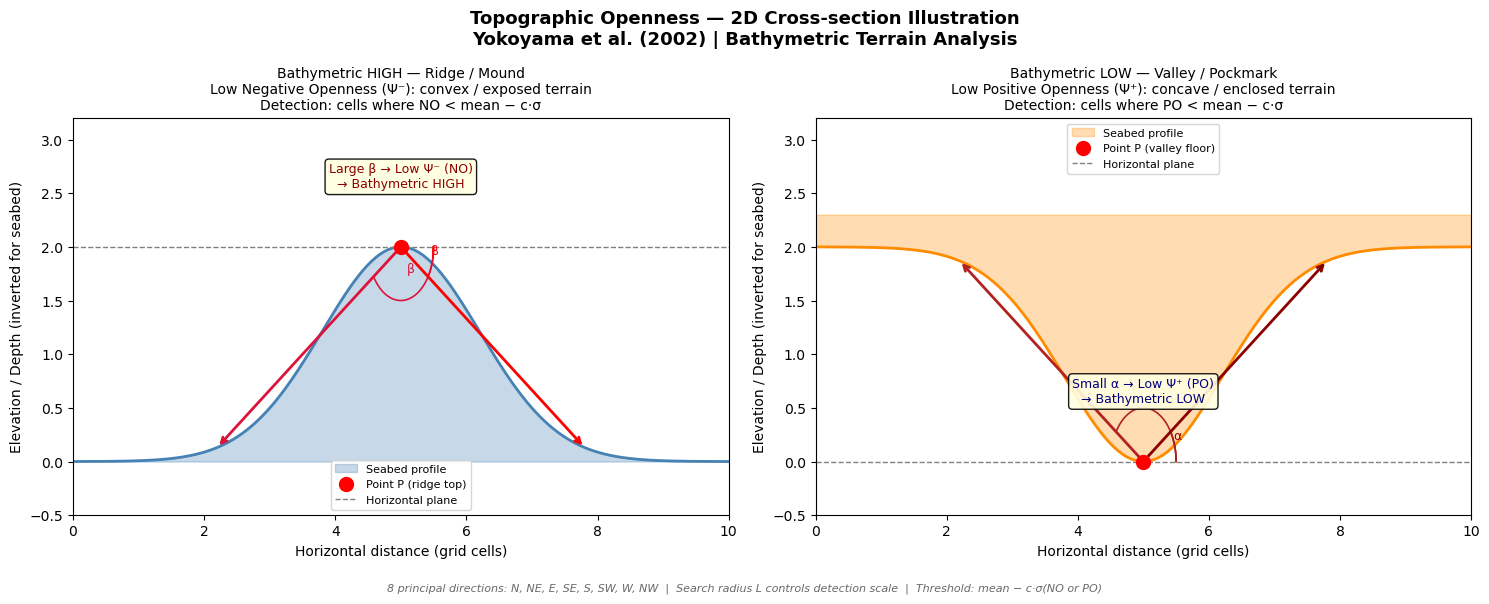

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================
# Topographic Openness — 2D Cross-section Illustration
# Yokoyama et al. (2002), adapted for bathymetric terrain
#
# BATHYMETRIC CONVENTION:
#   Bathymetric High (ridge/mound): LOW Negative Openness (NO)
#     → depression angles β large → Ψ⁻ small
#   Bathymetric Low (pockmark/valley): LOW Positive Openness (PO)
#     → zenith angles α small → Ψ⁺ small
#
# 8 principal directions collapsed to 2D: left & right rays
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    "Topographic Openness — 2D Cross-section Illustration\n"
    "Yokoyama et al. (2002) | Bathymetric Terrain Analysis",
    fontsize=13, fontweight='bold'
)

x = np.linspace(0, 10, 300)
ray_length = 2.8  # search radius L in grid units

def ridge(xi):
    """Bathymetric High — Gaussian bump"""
    return 2 * np.exp(-0.5 * ((xi - 5) / 1.2) ** 2)

def valley(xi):
    """Bathymetric Low — inverted Gaussian"""
    return -2 * np.exp(-0.5 * ((xi - 5) / 1.2) ** 2) + 2

# Helper: draw an arc showing the angle between horizontal and a ray
def draw_angle_arc(ax, cx, cz, dx, dz, radius, color, label, label_offset=(0.1, 0.1)):
    ray_angle = np.arctan2(dz, dx)
    horiz_angle = 0.0  # horizontal reference
    start = min(horiz_angle, ray_angle)
    end = max(horiz_angle, ray_angle)
    arc_angles = np.linspace(start, end, 40)
    arc_x = cx + radius * np.cos(arc_angles)
    arc_z = cz + radius * np.sin(arc_angles)
    ax.plot(arc_x, arc_z, color=color, lw=1.2, ls='-')
    mid = (start + end) / 2
    ax.text(cx + (radius + label_offset[0]) * np.cos(mid),
            cz + (radius + label_offset[1]) * np.sin(mid),
            label, color=color, fontsize=9, ha='center')

# ------------------------------------------------------------------
# LEFT: Bathymetric HIGH — Ridge / Mound
#   Low Negative Openness (Ψ⁻)
#   Depression angles β are LARGE → Ψ⁻ is SMALL
# ------------------------------------------------------------------
ax = axes[0]
z = ridge(x)
ax.fill_between(x, z, alpha=0.3, color='steelblue', label='Seabed profile')
ax.plot(x, z, color='steelblue', lw=2)

# Point P at ridge top
px, pz = 5.0, float(ridge(5.0))
ax.plot(px, pz, 'ro', ms=10, zorder=5, label='Point P (ridge top)')

# Horizontal reference line
ax.axhline(pz, color='gray', ls='--', lw=1, label='Horizontal plane')

# 8 directions → in 2D cross-section: left & right rays at equal spacing
# Directions: right = 0°, left = 180° (plus intermediate shown as offsets)
ray_dirs = [ray_length, -ray_length]  # right and left
ray_colors = ['red', 'crimson']
for rdx, col in zip(ray_dirs, ray_colors):
    ex = px + rdx
    ez = float(ridge(ex))
    # Arrow from P to surface horizon
    ax.annotate('', xy=(ex, ez), xytext=(px, pz),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    # Depression angle arc (ray goes downward from P → β is angle below horizontal)
    draw_angle_arc(ax, px, pz, rdx, ez - pz, radius=0.5,
                   color=col, label='β', label_offset=(0.05, -0.25))

ax.text(5.0, pz + 0.55,
        "Large β → Low Ψ⁻ (NO)\n→ Bathymetric HIGH",
        color='darkred', fontsize=9, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax.set_xlim(0, 10)
ax.set_ylim(-0.5, 3.2)
ax.set_title(
    "Bathymetric HIGH — Ridge / Mound\n"
    "Low Negative Openness (Ψ⁻): convex / exposed terrain\n"
    "Detection: cells where NO < mean − c·σ",
    fontsize=10
)
ax.set_xlabel("Horizontal distance (grid cells)")
ax.set_ylabel("Elevation / Depth (inverted for seabed)")
ax.legend(fontsize=8, loc='lower center')

# ------------------------------------------------------------------
# RIGHT: Bathymetric LOW — Valley / Pockmark
#   Low Positive Openness (Ψ⁺)
#   Zenith angles α are SMALL → Ψ⁺ is SMALL
# ------------------------------------------------------------------
ax2 = axes[1]
z2 = valley(x)
ax2.fill_between(x, z2, 2.3, alpha=0.3, color='darkorange', label='Seabed profile')
ax2.plot(x, z2, color='darkorange', lw=2)

# Point P at valley floor
px2, pz2 = 5.0, float(valley(5.0))
ax2.plot(px2, pz2, 'ro', ms=10, zorder=5, label='Point P (valley floor)')
ax2.axhline(pz2, color='gray', ls='--', lw=1, label='Horizontal plane')

# Left & right rays rising up the valley walls
ray_colors2 = ['darkred', 'firebrick']
for rdx, col in zip(ray_dirs, ray_colors2):
    ex2 = px2 + rdx
    ez2 = float(valley(ex2))
    ax2.annotate('', xy=(ex2, ez2), xytext=(px2, pz2),
                 arrowprops=dict(arrowstyle='->', color=col, lw=2))
    # Zenith angle arc (ray goes upward from P → α is angle above horizontal)
    draw_angle_arc(ax2, px2, pz2, rdx, ez2 - pz2, radius=0.5,
                   color=col, label='α', label_offset=(0.05, 0.2))

ax2.text(5.0, pz2 + 0.55,
         "Small α → Low Ψ⁺ (PO)\n→ Bathymetric LOW",
         color='navy', fontsize=9, ha='center',
         bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.9))

ax2.set_xlim(0, 10)
ax2.set_ylim(-0.5, 3.2)
ax2.set_title(
    "Bathymetric LOW — Valley / Pockmark\n"
    "Low Positive Openness (Ψ⁺): concave / enclosed terrain\n"
    "Detection: cells where PO < mean − c·σ",
    fontsize=10
)
ax2.set_xlabel("Horizontal distance (grid cells)")
ax2.set_ylabel("Elevation / Depth (inverted for seabed)")
ax2.legend(fontsize=8, loc='upper center')

# Footer
fig.text(0.5, 0.01,
         "8 principal directions: N, NE, E, SE, S, SW, W, NW  |  "
         "Search radius L controls detection scale  |  "
         "Threshold: mean − c·σ(NO or PO)",
         ha='center', fontsize=8, color='dimgray', style='italic')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## 4. Relationship Between Openness and Seabed Features

Because bathymetric data records **depth** (values increase downward), the openness measures behave in a specific way:

### Bathymetric Highs (seamounts, ridges, mounds, hummocks)

A bathymetric high is a location **shallower** than its surroundings — a "bump" in the seabed.

- **Negative Openness (NO)** is **small** at a bathymetric high.
  - Why? Looking outward from the top of a mound, the surrounding terrain drops away. The depression angles are large → negative openness is small.
  - In the GA-SaMMT openness tool, **negative openness is used to detect bathymetric highs** — regions with NO below a threshold are classified as high features.

### Bathymetric Lows (pockmarks, valleys, canyons, depressions)

A bathymetric low is a location **deeper** than its surroundings — a "pit" or "valley".

- **Positive Openness (PO)** is **small** at a bathymetric low.
  - Why? At the bottom of a pit, the surrounding terrain rises steeply. The zenith angles are small → positive openness is small.
  - In the GA-SaMMT openness tool, **positive openness is used to detect bathymetric lows** — regions with PO below a threshold are classified as low features.

Summary table:

| Feature type | Positive Openness (PO) | Negative Openness (NO) | Detection metric |
|---|---|---|---|
| **Bathymetric High** (ridge, mound) | High | **Low** | Low NO |
| **Flat seabed** | Medium | Medium | Neither |
| **Bathymetric Low** (pit, canyon) | **Low** | High | Low PO |

(circle-radius)=
## 5. The Openness Circle Radius Parameter

The **search radius** $L$ (called *Openness Circle Radius* in GA-SaMMT, measured in grid cell units) controls the **spatial scale** of the features being detected.

- **Small radius** (e.g., 10 cells) → sensitive to **fine-scale** features (small hummocks, micro-pockmarks)
- **Large radius** (e.g., 100 cells) → sensitive to **broad-scale** features (seamounts, large canyons)

This is analogous to the TPI (Topographic Position Index) radius parameter — it sets the neighbourhood window over which "context" is evaluated.

**Practical tip:** Run the tool at multiple radii and merge results to capture features at different scales.

## 6. Thresholding: How Features are Extracted

Once the NO or PO raster is computed, GA-SaMMT applies a **threshold** to identify candidate feature cells:

For **Bathymetric Highs** (using NO):
$$\text{NO\_threshold} = \overline{\text{NO}} - c \cdot \sigma_{\text{NO}}$$

- Cells where $\text{NO} < \text{NO\_threshold}$ are candidate high-feature cells.
- Parameter $c$ corresponds to the **NO STD Scale Large** parameter in the tool (e.g., $c = 1.0$ means the threshold is 1 standard deviation below the mean).
- A second, smaller threshold (**NO STD Scale Small**, e.g., $c = 0$) is used to capture the "tops" of the features more precisely.

For **Bathymetric Lows** (using PO):
$$\text{PO\_threshold} = \overline{\text{PO}} - c \cdot \sigma_{\text{PO}}$$

- Cells where $\text{PO} < \text{PO\_threshold}$ are candidate low-feature cells.

After thresholding, a minimum **area threshold** is applied to remove noise polygons that are too small to represent meaningful features.

## 7. Comparison with TPI (Topographic Position Index)

GA-SaMMT offers both TPI-based and Openness-based methods. Understanding their differences helps choose the right tool:

| Property | TPI | Openness |
|---|---|---|
| **What it measures** | Difference between a cell's elevation and the mean of its neighbourhood | Angular openness of the terrain from a point |
| **Computation** | Fast (mean filter) | Slower (8-direction ray casting) |
| **Sensitivity** | Linear differences in depth | Angular shape of terrain — better for asymmetric or complex features |
| **Best for** | General morphology, large datasets | Features with strong local curvature (pockmarks, volcanic cones) |
| **Scale control** | Radius of neighbourhood window | Search radius for ray casting |

The two methods are **complementary** — in practice, running both and comparing results (or combining outputs) gives the most robust feature detection.

## 8. Summary and Key Takeaways

| Concept | Definition | Key use |
|---|---|---|
| **Positive Openness (PO)** | Mean zenith angle to the highest point in each radial direction | Small PO → bathymetric low (pockmark, valley) |
| **Negative Openness (NO)** | Mean zenith angle to the lowest point in each radial direction | Small NO → bathymetric high (mound, ridge) |
| **Search radius** | Controls spatial scale of detection | Small radius = fine features; large radius = broad features |
| **STD threshold** | `mean - c×std` applied to NO or PO | Adjusting `c` controls sensitivity |